# Tahap 1: Gambaran Project dan Pembacaan Dataset

**Judul project:** Rancangan Mini Pipeline MLOps untuk Estimasi Tarif Transportasi Online Berdasarkan Data Perjalanan

Tahap ini digunakan untuk memahami data awal sebelum model dibuat. Dataset utama pada project ini adalah `data/raw/cab_rides.csv`, yang berisi informasi perjalanan seperti jarak, jenis layanan, rute, nama layanan, waktu, dan tarif.

Project ini hanya menggunakan data perjalanan dari `cab_rides.csv`.

Notebook ini hanya melakukan data understanding dan audit data. Raw dataset tidak dimodifikasi, dan belum ada proses training model pada tahap ini.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

project_root = Path.cwd()
if not (project_root / "data" / "raw").exists():
    project_root = project_root.parent

cab_rides_path = project_root / "data" / "raw" / "cab_rides.csv"

print("Path data perjalanan:", cab_rides_path)
print("Project ini hanya menggunakan data perjalanan dari cab_rides.csv.")


Path data perjalanan: d:\Tugas Kuliah\SEM 6\Proyek Data Mining\mlops-tarif-transportasi-online\data\raw\cab_rides.csv
Project ini hanya menggunakan data perjalanan dari cab_rides.csv.


In [2]:
cab_rides = pd.read_csv(cab_rides_path)

print("5 baris pertama cab_rides.csv")
display(cab_rides.head())


5 baris pertama cab_rides.csv


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.0,1.0,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.0,1.0,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.0,1.0,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.0,1.0,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.0,1.0,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [3]:
dataset_shapes = pd.DataFrame([
    {
        "Dataset": "cab_rides",
        "Role": "dataset perjalanan untuk audit dan baseline model",
        "Rows": cab_rides.shape[0],
        "Columns": cab_rides.shape[1],
    }
])

display(dataset_shapes)


,Dataset,Role,Rows,Columns
0,cab_rides,dataset perjalanan untuk audit dan baseline model,693071,10


# Tahap 2: Struktur Dataset dan Pemeriksaan Skema

Sebelum masuk ke pipeline MLOps, struktur dataset perlu dipahami terlebih dahulu. Pemeriksaan ini meliputi ukuran data, nama kolom, tipe data, missing value, dan jumlah nilai unik.

Fokus pemeriksaan adalah `cab_rides.csv` karena model menggunakan data perjalanan saja.


In [4]:
print("Kolom cab_rides.csv:")
display(pd.DataFrame({"column_name": cab_rides.columns}))


Kolom cab_rides.csv:


,column_name
0,distance
1,cab_type
2,time_stamp
3,destination
4,source
5,price
6,surge_multiplier
7,id
8,product_id
9,name


In [5]:
print("Tipe data cab_rides.csv:")
display(cab_rides.dtypes.rename("data_type").reset_index().rename(columns={"index": "column_name"}))


Tipe data cab_rides.csv:


,column_name,data_type
0,distance,float64
1,cab_type,object
2,time_stamp,int64
3,destination,object
4,source,object
5,price,float64
6,surge_multiplier,float64
7,id,object
8,product_id,object
9,name,object


In [6]:
print("Info cab_rides.csv:")
cab_rides.info()


Info cab_rides.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 693071 entries, 0 to 693070
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance          693071 non-null  float64
 1   cab_type          693071 non-null  object 
 2   time_stamp        693071 non-null  int64  
 3   destination       693071 non-null  object 
 4   source            693071 non-null  object 
 5   price             637976 non-null  float64
 6   surge_multiplier  693071 non-null  float64
 7   id                693071 non-null  object 
 8   product_id        693071 non-null  object 
 9   name              693071 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 52.9+ MB


In [7]:
print("Statistik dasar cab_rides.csv:")
display(cab_rides.describe(include="all").T)


Statistik dasar cab_rides.csv:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
distance,693071.0,NaN,NaN,NaN,2.18943,1.138937,0.02,1.28,2.16,2.92,7.86
cab_type,693071,2,Uber,385663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_stamp,693071.0,NaN,NaN,NaN,1544045709764.357178,689192492.400411,1543203646318.0,1543443968356.5,1543737477529.0,1544827508976.5,1545160510943.0
destination,693071,12,Financial District,58851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source,693071,12,Financial District,58857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,637976.0,NaN,NaN,NaN,16.545125,9.324359,2.5,9.0,13.5,22.5,97.5
surge_multiplier,693071.0,NaN,NaN,NaN,1.01387,0.091641,1.0,1.0,1.0,1.0,3.0
id,693071,693071,e7fdc087-fe86-40a5-a3c3-3b2a8badcbda,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,693071,13,6f72dfc5-27f1-42e8-84db-ccc7a75f6969,55096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,693071,13,UberXL,55096,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
cab_numeric_columns = cab_rides.select_dtypes(include=np.number).columns.tolist()
cab_categorical_columns = cab_rides.select_dtypes(exclude=np.number).columns.tolist()

print("Kolom numerik cab_rides:", cab_numeric_columns)
print("Kolom kategorikal cab_rides:", cab_categorical_columns)


Kolom numerik cab_rides: ['distance', 'time_stamp', 'price', 'surge_multiplier']
Kolom kategorikal cab_rides: ['cab_type', 'destination', 'source', 'id', 'product_id', 'name']


In [9]:
def create_schema_summary(df, dataset_name):
    return pd.DataFrame({
        "dataset": dataset_name,
        "column_name": df.columns,
        "data_type": [str(dtype) for dtype in df.dtypes],
        "missing_values": df.isna().sum().values,
        "unique_values": df.nunique(dropna=True).values,
    })

schema_summary = create_schema_summary(cab_rides, "cab_rides")
display(schema_summary)


,dataset,column_name,data_type,missing_values,unique_values
0,cab_rides,distance,float64,0,549
1,cab_rides,cab_type,object,0,2
2,cab_rides,time_stamp,int64,0,114335
3,cab_rides,destination,object,0,12
4,cab_rides,source,object,0,12
5,cab_rides,price,float64,55095,147
6,cab_rides,surge_multiplier,float64,0,7
7,cab_rides,id,object,0,693071
8,cab_rides,product_id,object,0,13
9,cab_rides,name,object,0,13


# Tahap 3: Pemahaman Target dan Fitur

Target prediksi pada project ini adalah `price`. Karena `price` berbentuk nilai numerik tarif, problem ini termasuk **regression**.

Fitur utama yang relevan dari data perjalanan adalah `distance`, `cab_type`, `source`, `destination`, `name`, dan `time_stamp`. Pada tahap preprocessing, `time_stamp` akan diubah menjadi fitur waktu seperti `hour`, `day`, `month`, dan `day_of_week`.

Beberapa kolom tidak digunakan sebagai fitur baseline: `id` dan `product_id` adalah identifier, `price` adalah target, dan `surge_multiplier` dikeluarkan karena sangat dekat dengan mekanisme pricing.


In [10]:
target_column = "price"

if target_column in cab_rides.columns:
    print("Target column 'price' exists in cab_rides.csv.")
else:
    print("Target column 'price' is missing. This must be fixed before modeling.")


Target column 'price' exists in cab_rides.csv.


In [11]:
missing_price_rows = cab_rides["price"].isna().sum()
missing_price_pct = missing_price_rows / len(cab_rides) * 100

print(f"Rows with missing price: {missing_price_rows:,}")
print(f"Percentage of missing price: {missing_price_pct:.2f}%")


Rows with missing price: 55,095
Percentage of missing price: 7.95%


Statistik dasar price:


,price
count,637976.000000
mean,16.545125
std,9.324359
min,2.500000
25%,9.000000
50%,13.500000
75%,22.500000
max,97.500000


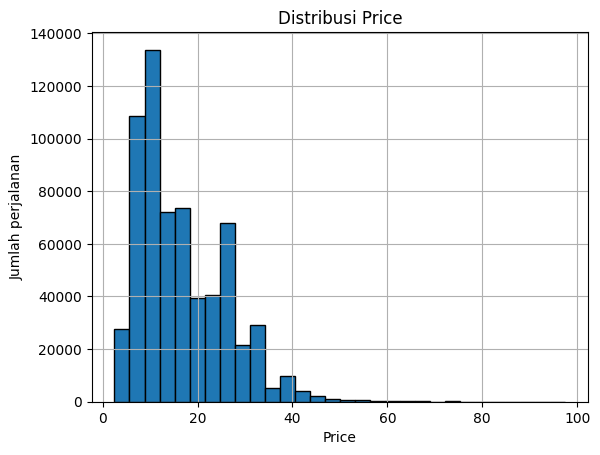

In [12]:
print("Statistik dasar price:")
display(cab_rides["price"].describe().to_frame("price"))

cab_rides["price"].dropna().hist(bins=30, edgecolor="black")
plt.title("Distribusi Price")
plt.xlabel("Price")
plt.ylabel("Jumlah perjalanan")
plt.show()


Statistik dasar distance:


,distance
count,693071.000000
mean,2.189430
std,1.138937
min,0.020000
25%,1.280000
50%,2.160000
75%,2.920000
max,7.860000


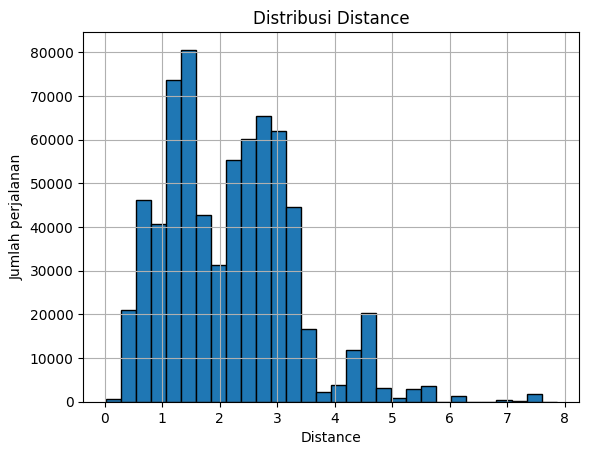

In [13]:
print("Statistik dasar distance:")
display(cab_rides["distance"].describe().to_frame("distance"))

cab_rides["distance"].dropna().hist(bins=30, edgecolor="black")
plt.title("Distribusi Distance")
plt.xlabel("Distance")
plt.ylabel("Jumlah perjalanan")
plt.show()


In [14]:
for column in ["cab_type", "source", "destination", "name"]:
    print(f"Value counts for {column}:")
    display(cab_rides[column].value_counts(dropna=False).rename_axis(column).reset_index(name="count"))


Value counts for cab_type:


,cab_type,count
0,Uber,385663
1,Lyft,307408


Value counts for source:


,source,count
0,Financial District,58857
1,Theatre District,57813
2,Back Bay,57792
3,Boston University,57764
4,North End,57763
5,Fenway,57757
6,Northeastern University,57756
7,South Station,57750
8,Haymarket Square,57736
9,West End,57562


Value counts for destination:


,destination,count
0,Financial District,58851
1,Theatre District,57798
2,Back Bay,57780
3,Haymarket Square,57764
4,Boston University,57764
5,Fenway,57757
6,North End,57756
7,Northeastern University,57755
8,South Station,57749
9,West End,57575


Value counts for name:


,name,count
0,UberXL,55096
1,WAV,55096
2,Black SUV,55096
3,Black,55095
4,Taxi,55095
5,UberX,55094
6,UberPool,55091
7,Lux,51235
8,Lux Black XL,51235
9,Lyft,51235


In [15]:
valid_price_distance = cab_rides.dropna(subset=["price", "distance"]).copy()
valid_price_distance["distance_bin"] = pd.cut(valid_price_distance["distance"], bins=10)

distance_price_summary = (
    valid_price_distance
    .groupby("distance_bin", observed=True)
    .agg(
        ride_count=("price", "size"),
        average_distance=("distance", "mean"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
    )
    .reset_index()
)

display(distance_price_summary)


,distance_bin,ride_count,average_distance,average_price,median_price
0,"(0.0122, 0.804]",62244,0.582350,12.517959,10.5
1,"(0.804, 1.588]",179352,1.254399,13.632071,12.0
2,"(1.588, 2.372]",118614,2.009127,15.998349,14.0
3,"(2.372, 3.156]",172412,2.771393,18.083805,16.5
4,"(3.156, 3.94]",59094,3.340930,20.293411,19.5
5,"(3.94, 4.724]",33216,4.451817,23.434620,22.5
6,"(4.724, 5.508]",6714,5.080143,25.910262,26.0
7,"(5.508, 6.292]",4176,5.777126,25.139368,21.5
8,"(6.292, 7.076]",354,6.913220,26.937853,24.0
9,"(7.076, 7.86]",1800,7.420033,27.605556,25.0


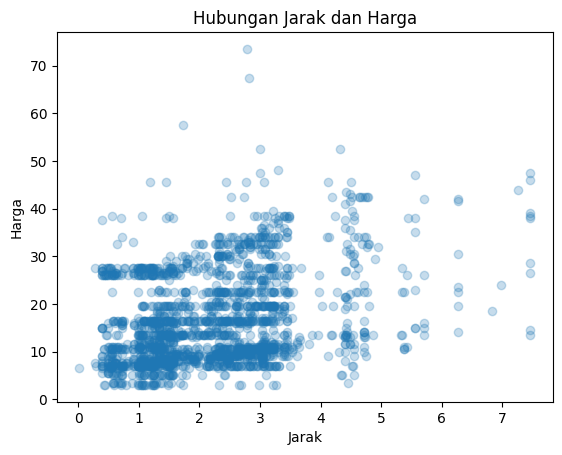

In [22]:
plot_sample = valid_price_distance.sample(n=min(2000, len(valid_price_distance)), random_state=42)

plt.scatter(plot_sample["distance"], plot_sample["price"], alpha=0.25)
plt.title("Hubungan Jarak dan Harga")
plt.xlabel("Jarak")
plt.ylabel("Harga")
plt.show()


# Tahap 4: Audit Kualitas Data dan Pemeriksaan Validasi

Validasi data merupakan bagian dari Continuous Integration (CI) dalam pipeline MLOps. Sebelum data dipakai untuk training, notebook ini mengecek apakah data perjalanan lengkap, logis, dan aman untuk diproses.

Check utama pada dataset `cab_rides.csv` meliputi keberadaan target `price`, missing target, `distance <= 0`, `price <= 0`, missing value pada `source`, `destination`, `cab_type`, dan `name`, serta duplicate row.


In [17]:
print("Total missing value per kolom pada cab_rides.csv:")
display(cab_rides.isna().sum().sort_values(ascending=False).rename("missing_values").reset_index().rename(columns={"index": "column_name"}))


Total missing value per kolom pada cab_rides.csv:


,column_name,missing_values
0,price,55095
1,distance,0
2,cab_type,0
3,time_stamp,0
4,destination,0
5,source,0
6,surge_multiplier,0
7,id,0
8,product_id,0
9,name,0


In [18]:
duplicate_summary = pd.DataFrame([
    {"Dataset": "cab_rides", "Role": "main", "Duplicate Rows": int(cab_rides.duplicated().sum())}
])

display(duplicate_summary)


,Dataset,Role,Duplicate Rows
0,cab_rides,main,0


In [19]:
row_checks = {
    "Missing price": cab_rides["price"].isna(),
    "Distance <= 0": cab_rides["distance"] <= 0,
    "Price <= 0": cab_rides["price"] <= 0,
    "Missing source": cab_rides["source"].isna(),
    "Missing destination": cab_rides["destination"].isna(),
    "Missing cab_type": cab_rides["cab_type"].isna(),
    "Missing name": cab_rides["name"].isna(),
}

row_check_summary = pd.DataFrame({
    "Check Name": list(row_checks.keys()),
    "Failed Rows": [int(mask.sum()) for mask in row_checks.values()],
})

display(row_check_summary)


,Check Name,Failed Rows
0,Missing price,55095
1,Distance <= 0,0
2,Price <= 0,0
3,Missing source,0
4,Missing destination,0
5,Missing cab_type,0
6,Missing name,0


In [20]:
def missing_percentage_table(df, dataset_name):
    missing_count = df.isna().sum()
    missing_percentage = missing_count / len(df) * 100
    return pd.DataFrame({
        "dataset": dataset_name,
        "column_name": df.columns,
        "missing_values": missing_count.values,
        "missing_percentage": missing_percentage.round(2).values,
    })

missing_percentage_summary = missing_percentage_table(cab_rides, "cab_rides")
display(missing_percentage_summary)


,dataset,column_name,missing_values,missing_percentage
0,cab_rides,distance,0,0.00
1,cab_rides,cab_type,0,0.00
2,cab_rides,time_stamp,0,0.00
3,cab_rides,destination,0,0.00
4,cab_rides,source,0,0.00
5,cab_rides,price,55095,7.95
6,cab_rides,surge_multiplier,0,0.00
7,cab_rides,id,0,0.00
8,cab_rides,product_id,0,0.00
9,cab_rides,name,0,0.00


In [21]:
def status_from_count(failed_rows, issue_status):
    if failed_rows == 0:
        return "PASS"
    return issue_status

price_column_failed = 0 if "price" in cab_rides.columns else len(cab_rides)
missing_price_failed = int(cab_rides["price"].isna().sum()) if "price" in cab_rides.columns else len(cab_rides)
price_le_zero_failed = int((cab_rides["price"].dropna() <= 0).sum()) if "price" in cab_rides.columns else len(cab_rides)
validation_summary = pd.DataFrame([
    {
        "Check Name": "Target column exists",
        "Rule": "Column 'price' must exist in cab_rides",
        "Failed Rows": price_column_failed,
        "Status": status_from_count(price_column_failed, "FAIL"),
        "Recommendation": "Keep 'price' as the supervised learning target.",
    },
    {
        "Check Name": "Missing price",
        "Rule": "Price should be available for training rows",
        "Failed Rows": missing_price_failed,
        "Status": status_from_count(missing_price_failed, "WARNING"),
        "Recommendation": "Remove rows with missing target before model training.",
    },
    {
        "Check Name": "Distance validity",
        "Rule": "Distance must be greater than 0",
        "Failed Rows": int((cab_rides["distance"] <= 0).sum()),
        "Status": status_from_count(int((cab_rides["distance"] <= 0).sum()), "FAIL"),
        "Recommendation": "Investigate or remove invalid distance rows if found.",
    },
    {
        "Check Name": "Price validity",
        "Rule": "Price must be greater than 0 when present",
        "Failed Rows": price_le_zero_failed,
        "Status": status_from_count(price_le_zero_failed, "FAIL"),
        "Recommendation": "Investigate impossible fare values if found.",
    },
    {
        "Check Name": "Missing source",
        "Rule": "Source should not be missing",
        "Failed Rows": int(cab_rides["source"].isna().sum()),
        "Status": status_from_count(int(cab_rides["source"].isna().sum()), "FAIL"),
        "Recommendation": "Fill only if business rules are clear; otherwise remove affected rows.",
    },
    {
        "Check Name": "Missing destination",
        "Rule": "Destination should not be missing",
        "Failed Rows": int(cab_rides["destination"].isna().sum()),
        "Status": status_from_count(int(cab_rides["destination"].isna().sum()), "FAIL"),
        "Recommendation": "Fill only if business rules are clear; otherwise remove affected rows.",
    },
    {
        "Check Name": "Missing cab_type",
        "Rule": "Cab type should not be missing",
        "Failed Rows": int(cab_rides["cab_type"].isna().sum()),
        "Status": status_from_count(int(cab_rides["cab_type"].isna().sum()), "FAIL"),
        "Recommendation": "Investigate missing service platform values if found.",
    },
    {
        "Check Name": "Missing name",
        "Rule": "Ride product name should not be missing",
        "Failed Rows": int(cab_rides["name"].isna().sum()),
        "Status": status_from_count(int(cab_rides["name"].isna().sum()), "WARNING"),
        "Recommendation": "Handle missing product names before categorical encoding.",
    },
    {
        "Check Name": "Duplicate cab rows",
        "Rule": "Exact duplicate rows should be reviewed",
        "Failed Rows": int(cab_rides.duplicated().sum()),
        "Status": status_from_count(int(cab_rides.duplicated().sum()), "WARNING"),
        "Recommendation": "Remove duplicates only after confirming they are not valid repeated rides.",
    },
])

display(validation_summary)


,Check Name,Rule,Failed Rows,Status,Recommendation
0,Target column exists,Column 'price' must exist in cab_rides,0,PASS,Keep 'price' as the supervised learning target.
1,Missing price,Price should be available for training rows,55095,WARNING,Remove rows with missing target before model t...
2,Distance validity,Distance must be greater than 0,0,PASS,Investigate or remove invalid distance rows if...
3,Price validity,Price must be greater than 0 when present,0,PASS,Investigate impossible fare values if found.
4,Missing source,Source should not be missing,0,PASS,Fill only if business rules are clear; otherwi...
5,Missing destination,Destination should not be missing,0,PASS,Fill only if business rules are clear; otherwi...
6,Missing cab_type,Cab type should not be missing,0,PASS,Investigate missing service platform values if...
7,Missing name,Ride product name should not be missing,0,PASS,Handle missing product names before categorica...
8,Duplicate cab rows,Exact duplicate rows should be reviewed,0,PASS,Remove duplicates only after confirming they a...


# Tahap 5: Temuan Awal dan Catatan Persiapan MLOps

Hasil audit menunjukkan bahwa `cab_rides.csv` layak digunakan untuk tahap berikutnya setelah baris dengan `price` missing dibersihkan. Kolom `source`, `destination`, `cab_type`, dan `name` lengkap, sehingga dapat dipakai sebagai fitur kategorikal.

Fitur baseline yang disiapkan berasal dari data perjalanan. Temuan dari tahap ini mendukung CI checklist untuk schema check, missing-value check, duplicate check, dan validasi logika dasar sebelum training.


# Ringkasan Tahap 1

- Dataset perjalanan berhasil dibaca dari `cab_rides.csv` dengan 693.071 baris dan 10 kolom.
- Target `price` sudah ditentukan dan problem type adalah regression.
- Missing `price` ditemukan sebanyak 55.095 baris.
- Baris dengan `price` valid berjumlah 637.976 baris.
- `distance <= 0` berjumlah 0 baris.
- `price <= 0` pada data dengan `price` tidak missing berjumlah 0 baris.
- Kolom `source`, `destination`, `cab_type`, dan `name` tidak memiliki missing value.
- Exact duplicate row pada `cab_rides.csv` berjumlah 0.
- Data layak dilanjutkan ke tahap preprocessing.
